# US Macroeconomic Data Preparation

**Imports & Setup**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

from fredapi import Fred

plt.style.use("seaborn-v0_8-darkgrid")

# ── FRED API key
# Replace with your own free key from https://fred.stlouisfed.org/docs/api/api_key.html
FRED_API_KEY = "Your key"
fred = Fred(api_key=FRED_API_KEY)

# ── Date range
START = "2007-01-01"
END   = "2023-12-31"

FRED_SERIES = {
    "CPIAUCSL" : "CPI (Inflation)",
    "UNRATE"   : "Unemployment Rate (%)",
    "FEDFUNDS" : "Fed Funds Rate (%)",
    "INDPRO"   : "Industrial Production Index",
}

print("Date range :", START, " ->  ", END)
print("Series     :", list(FRED_SERIES.keys()))

Date range : 2007-01-01  ->   2023-12-31
Series     : ['CPIAUCSL', 'UNRATE', 'FEDFUNDS', 'INDPRO']


**Download Data from FRED API**

In [2]:
def fetch_fred(series_id, label, start, end):
    s = fred.get_series(series_id, observation_start=start, observation_end=end)
    s.index = pd.to_datetime(s.index)
    s.name  = series_id
    print(f"  [{series_id}]  {label:<35}  {len(s):>4} obs  "
          f"{s.index[0].date()} -> {s.index[-1].date()}")
    return s

print("Fetching macroeconomic data from FRED...")

cpi      = fetch_fred("CPIAUCSL", "Consumer Price Index",        START, END)
unrate   = fetch_fred("UNRATE",   "Unemployment Rate",           START, END)
fedfunds = fetch_fred("FEDFUNDS", "Fed Funds Rate",              START, END)
indpro   = fetch_fred("INDPRO",   "Industrial Production Index", START, END)

# Merge into a single monthly DataFrame
macro_raw = pd.concat([cpi, unrate, fedfunds, indpro], axis=1)
macro_raw = macro_raw.resample("MS").last()
macro_raw = macro_raw.loc[START:END]
macro_raw.index.name = "Date"

print("Combined shape :", macro_raw.shape)
print("Period         :", macro_raw.index[0].date(), " ->  ", macro_raw.index[-1].date())
macro_raw.head(8)

Fetching macroeconomic data from FRED...
  [CPIAUCSL]  Consumer Price Index                  204 obs  2007-01-01 -> 2023-12-01
  [UNRATE]  Unemployment Rate                     204 obs  2007-01-01 -> 2023-12-01
  [FEDFUNDS]  Fed Funds Rate                        204 obs  2007-01-01 -> 2023-12-01
  [INDPRO]  Industrial Production Index           204 obs  2007-01-01 -> 2023-12-01
Combined shape : (204, 4)
Period         : 2007-01-01  ->   2023-12-01


,CPIAUCSL,UNRATE,FEDFUNDS,INDPRO
Date,,,,
2007-01-01,203.437,4.6,5.25,99.8346
2007-02-01,204.226,4.5,5.26,100.7753
2007-03-01,205.288,4.4,5.26,100.9547
2007-04-01,205.904,4.5,5.25,101.6334
2007-05-01,206.755,4.4,5.25,101.7306
2007-06-01,207.234,4.6,5.25,101.7893
2007-07-01,207.603,4.7,5.26,101.6672
2007-08-01,207.667,4.6,5.02,101.8630


**Feature Engineering**

In [3]:
macro = macro_raw.copy()

# Inflation: Month-over-Month and Year-over-Year % change of CPI
macro["Inflation_MoM"] = macro["CPIAUCSL"].pct_change() * 100
macro["Inflation_YoY"] = macro["CPIAUCSL"].pct_change(12) * 100

# Industrial Production: MoM % change
macro["IP_MoM"] = macro["INDPRO"].pct_change() * 100

# UNRATE and FEDFUNDS are already in % units - no transform needed

# Drop NaN rows introduced by pct_change lags
macro = macro.dropna()

print("Engineered columns:")
for col in macro.columns:
    print("  -", col)
print("\nFinal shape:", macro.shape)
macro.describe().round(3)

Engineered columns:
  - CPIAUCSL
  - UNRATE
  - FEDFUNDS
  - INDPRO
  - Inflation_MoM
  - Inflation_YoY
  - IP_MoM

Final shape: (192, 7)


,CPIAUCSL,UNRATE,FEDFUNDS,INDPRO,Inflation_MoM,Inflation_YoY,IP_MoM
count,192.000,192.000,192.000,192.000,192.000,192.000,192.000
mean,245.507,6.126,0.961,98.267,0.198,2.457,0.001
std,25.594,2.283,1.375,4.561,0.327,2.114,1.373
min,211.398,3.400,0.050,84.562,-1.771,-1.959,-13.188
25%,227.687,4.000,0.100,96.740,0.051,1.233,-0.321
50%,238.025,5.550,0.180,99.729,0.208,1.987,0.100
75%,257.070,8.025,1.550,101.256,0.335,3.163,0.469
max,308.741,14.800,5.330,104.100,1.256,8.979,6.553


**Visualisation**

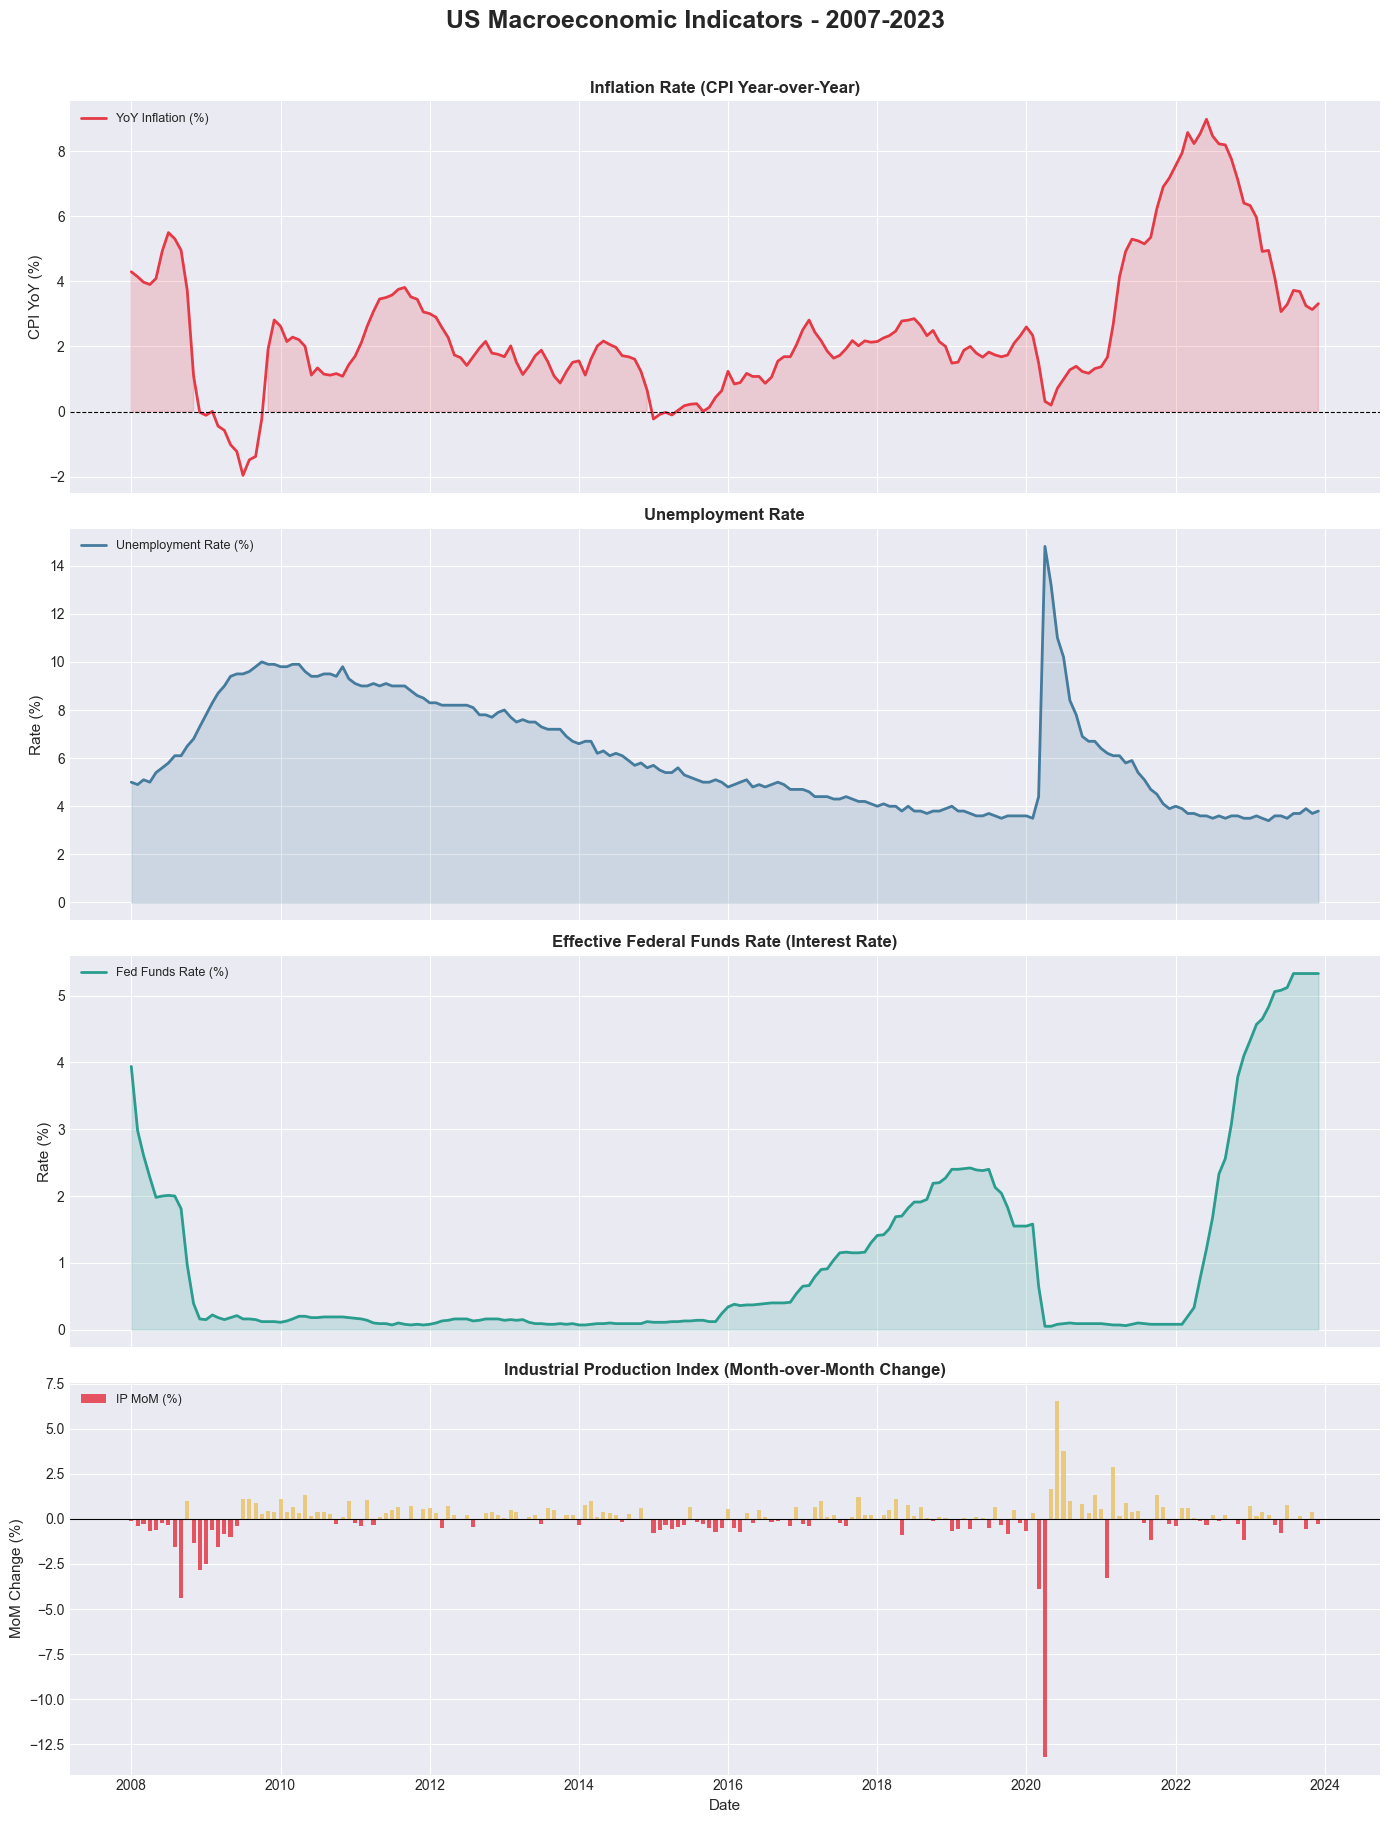

Plot saved to ../../plots/US/us_macro_indicators_2007_2023.png


In [9]:
PALETTE = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A"]


fig, axes = plt.subplots(4, 1, figsize=(14, 18), sharex=True)
fig.suptitle("US Macroeconomic Indicators - 2007-2023",
             fontsize=18, fontweight="bold", y=1.01)

# Panel 1: Inflation YoY
ax = axes[0]
ax.plot(macro.index, macro["Inflation_YoY"], color=PALETTE[0],
        linewidth=2, label="YoY Inflation (%)")
ax.fill_between(macro.index, macro["Inflation_YoY"], 0,
                where=(macro["Inflation_YoY"] >= 0),
                alpha=0.18, color=PALETTE[0])
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("CPI YoY (%)", fontsize=11)
ax.set_title("Inflation Rate (CPI Year-over-Year)", fontsize=12, fontweight="semibold")
ax.legend(fontsize=9, loc="upper left")

# Panel 2: Unemployment Rate
ax = axes[1]
ax.plot(macro.index, macro["UNRATE"], color=PALETTE[1],
        linewidth=2, label="Unemployment Rate (%)")
ax.fill_between(macro.index, macro["UNRATE"], alpha=0.18, color=PALETTE[1])
ax.set_ylabel("Rate (%)", fontsize=11)
ax.set_title("Unemployment Rate", fontsize=12, fontweight="semibold")
ax.legend(fontsize=9, loc="upper left")

# Panel 3: Federal Funds Rate
ax = axes[2]
ax.plot(macro.index, macro["FEDFUNDS"], color=PALETTE[2],
        linewidth=2, label="Fed Funds Rate (%)")
ax.fill_between(macro.index, macro["FEDFUNDS"], alpha=0.18, color=PALETTE[2])
ax.set_ylabel("Rate (%)", fontsize=11)
ax.set_title("Effective Federal Funds Rate (Interest Rate)",
             fontsize=12, fontweight="semibold")
ax.legend(fontsize=9, loc="upper left")

# Panel 4: Industrial Production MoM %
ax = axes[3]
bar_colors = [PALETTE[3] if v >= 0 else PALETTE[0] for v in macro["IP_MoM"]]
ax.bar(macro.index, macro["IP_MoM"], width=20,
       color=bar_colors, alpha=0.85, label="IP MoM (%)")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("MoM Change (%)", fontsize=11)
ax.set_title("Industrial Production Index (Month-over-Month Change)",
             fontsize=12, fontweight="semibold")
ax.legend(fontsize=9, loc="upper left")

# Shared x-axis
axes[-1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[-1].set_xlabel("Date", fontsize=11)
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=0, fontsize=10)

plt.tight_layout()

import os
os.makedirs("../../plots/US", exist_ok=True)
plt.savefig("../../plots/US/us_macro_indicators_2007_2023.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to ../../plots/US/us_macro_indicators_2007_2023.png")

# FinBERT Sentiment Scoring

In [ ]:
# TODO